### Plot of heatmap of node communities  
Import packages

In [1]:
import sys
import pickle
sys.path.append('../analysis')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from collections import deque
from MBN_Res_Constrn import MBN_RC
from ClusterTracking import SCTA

Import MB_communities

In [2]:
with open('../Mouse brain network/MouseBrainLib/mb_communities_dict.pickle', 'rb') as f:
    _x = pickle.load(f)

Import  
1. iteration data
2. node communities data (threshold=0.5)
3. local order data

In [3]:
df_itr=pd.read_pickle('../../data/raw/FN/itr_data_fn.bz2')
df_nc=pd.read_pickle('../../data/raw/check_20/nc_fn_20.bz2')
df_lo=pd.read_pickle('../../data/raw/FN/l200.bz2')
df_toe = pd.read_pickle('../../data/raw/check_20/toe_fn_20.bz2')

Make node_communities data according to MBcommunity ordered by synchronisation  
Order:  or,ol,ht,v,m,hc,mb,hb  


In [2]:
df_itr=pd.read_pickle('../../data/raw/FN/itr_data_fn.bz2')

NameError: name 'pd' is not defined

In [115]:
df_nc=pd.read_pickle('../../data/raw/check_20/nc_fn_20.bz2')

In [112]:
df_nc.loc[2]

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,10.0,11.0,10.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,13.0,14.0,13.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,13.0,14.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,14.0,15.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,14.0,15.0,16.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,75.0,0.0,75.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,75.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4996,75.0,0.0,75.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,75.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,75.0,0.0,75.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,75.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,75.0,0.0,75.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,75.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
df_reset = df_lo.reset_index()
# reset outer index values i.e iteration numbers
itr=df_reset['level_0'].drop_duplicates()
# itr_val contains iteration numbers which had transitions
itr_val=itr.values


In [22]:
itr_val

array([  5,   8,   9,  11,  12,  14,  15,  16,  18,  19,  20,  22,  23,
        24,  25,  27,  30,  31,  33,  34,  35,  36,  37,  38,  40,  44,
        46,  47,  51,  52,  53,  54,  56,  57,  59,  61,  62,  63,  65,
        66,  71,  73,  75,  80,  81,  84,  85,  87,  94,  97,  98,  99,
       102, 103, 104, 108, 109, 110, 112, 114, 115, 119, 120, 122, 124,
       126, 127, 129, 130, 131, 132, 135, 136, 138, 139, 140, 142, 148,
       154, 156, 157, 158, 160, 161, 163, 164, 165, 167, 169, 170, 171,
       179, 181, 183, 189, 190, 191, 194, 195, 199])

In [ ]:
m_lo = (df_lo.loc[5].iloc[0:426]).values

In [43]:
a=m_lo.T
m_lo_ar=a[:,new_order]

In [44]:
m_lo_ar.shape

(5000, 426)

In [4]:
df_nc.loc[1].shape

(5000, 426)

In [114]:
desired_keys = [3,6,4,2,0,7,1,5]
_x_rearrange = {key: _x[key] for key in desired_keys}

desired_order = [item for sublist in _x_rearrange.values() for item in sublist]
rearranged_matrix = matrix[:, desired_order]

Within each community sort the nodes in decreasing order of total time spent in the final cluster

In [84]:
#choosing node 23 as it is from orbital area,making sure it enters the main cluster
main_cluster_index = (df_nc.loc[1])[23].value_counts().index[1]
#plt.hist(matrix[4000, :], bins=100, range=(1, 5));

In [85]:
main_cluster_index

3.0

In [36]:
rearranged_matrix.shape

(5000, 426)

In [86]:
_x_rearrange.keys()

dict_keys([3, 6, 4, 2, 0, 7, 1, 5])

In [6]:
len_comm=[len(v) for v in _x_rearrange.values()]
len_comm

[34, 36, 44, 50, 56, 50, 70, 86]

Re-arranging ToE data in MB community order of nodes

In [115]:
toe_matrix=df_toe.values
toe_matrix_rearr = toe_matrix[:,desired_order]

In [120]:
toe_matrix[:,22]

array([4956., 4999., 3408., 4430., 4062., 3427., 4999., 3663., 4347.,
       3672., 4987., 3361., 4346., 3481., 3570., 3656., 4999., 4999.,
       4038., 3413.])

In [122]:
toe_matrix_rearr[0,0]

4956.0

In [123]:
toe_matrix.shape

(20, 426)

In [124]:
rearranged_matrix.shape

(5000, 426)

In [133]:
time_spent=0
for i in range(4956,5000):
    if rearranged_matrix[i,0] == main_cluster_index:
        time_spent+=1
    

In [134]:
time_spent

44

In [132]:
toe_st=toe_matrix_rearr[0,0]
print(toe_st)

4956.0


Therefore, to calculate time spent just count how many times it was in main cluster

In [155]:
rearranged_matrix.shape

(5000, 426)

In [162]:
main_cluster_index

3.0

Calculating time spent by each node of a community in main cluster

In [175]:
time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
for i in range(34,34+len_comm[1]):
    
    for j in range(0,5000):
                
        if rearranged_matrix[j][i] == main_cluster_index:
            time_spent+=1
                    
        else:
            pass
        
    ts.append(time_spent)
    



Complete code to calculate time spent for every node in matrix    

In [196]:
time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
for l in range(0,8):
    for i in range(c,last):
        
        for j in range(0,5000):
                    
            if rearranged_matrix[j][i] == main_cluster_index:
                time_spent+=1
                        
            else:
                pass
            
        ts.append(time_spent)
        time_spent=0
    
    c=len_comm[com_count]
    com_count+=1
    if com_count<8:
        last=c+len_comm[com_count]
    else:
        break



Sort by time spent for each MB community

In [220]:
time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
for l in range(0,8):
    #l for iterating communities
    for i in range(c,last):
        #i for iterating node
        
        for j in range(0,5000):
            #j for iterating timestep
                    
            if rearranged_matrix[j][i] == main_cluster_index:
                time_spent+=1
                        
            else:
                pass
            
        ts.append(time_spent)
        time_spent=0

    
    c=len_comm[com_count]
    com_count+=1
    if com_count<8:
        last=c+len_comm[com_count]
    else:
        break



#### Adding sort by time spent
final

In [247]:
time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
dict_sort={}

for l in range(0,8):
    #l for iterating communities
    keys=[]
    values=[]
    for i in range(c,last):
        #i for iterating node
        
        for j in range(0,5000):
            #j for iterating timestep
                    
            if rearranged_matrix[j][i] == main_cluster_index:
                time_spent+=1
                        
            else:
                pass
            
        ts.append(time_spent)
        time_spent=0

    keys=list(range(c,last))
    values=ts[c:last]
    dict_0=dict(zip(keys,values))
    sorted_dict_dum = {k: v for k, v in sorted(dict_0.items(), key=lambda item: item[1],reverse=True)}
    dict_sort = dict_sort | sorted_dict_dum
    c=last
    com_count+=1
    if com_count<8:
        last=last+len_comm[com_count]
    else:
        break



New order with node in a community sorted in descending order

In [252]:
new_order=list(dict_sort.keys())
print(new_order)

[25, 7, 6, 10, 26, 22, 4, 24, 1, 31, 19, 14, 15, 11, 12, 5, 17, 16, 30, 29, 8, 33, 32, 27, 0, 13, 18, 9, 23, 2, 3, 28, 21, 20, 46, 39, 41, 53, 50, 35, 45, 43, 36, 54, 37, 38, 57, 51, 60, 42, 40, 56, 63, 49, 48, 68, 34, 55, 64, 69, 59, 61, 52, 44, 67, 66, 62, 65, 58, 47, 72, 76, 71, 92, 111, 73, 88, 93, 97, 109, 77, 90, 78, 100, 107, 99, 79, 110, 85, 94, 86, 98, 103, 83, 112, 105, 104, 70, 89, 84, 91, 81, 82, 75, 102, 106, 96, 87, 95, 74, 108, 101, 80, 113, 131, 129, 154, 117, 132, 135, 139, 157, 140, 134, 133, 137, 150, 120, 115, 141, 124, 114, 119, 130, 153, 128, 125, 142, 118, 158, 138, 155, 122, 160, 123, 127, 149, 159, 136, 144, 147, 116, 156, 148, 152, 145, 126, 161, 121, 143, 146, 163, 162, 151, 179, 180, 177, 208, 206, 188, 215, 181, 192, 210, 184, 209, 187, 205, 216, 189, 164, 218, 217, 191, 219, 178, 190, 176, 185, 186, 170, 172, 204, 213, 175, 200, 171, 203, 198, 182, 207, 214, 211, 194, 166, 199, 196, 183, 197, 168, 212, 202, 195, 201, 174, 173, 169, 193, 165, 167, 225, 255,

In [253]:
final_matrix = rearranged_matrix[:, new_order]

Plotting global order

In [10]:
dt=0.05
#put  iteration number for which you want to plot
df_smooth=df_itr['9'].rolling(window=800, center=True).mean()

#defining time and timesteps for data
time_steps = list(range(0,df_smooth.shape[0]))

time=np.multiply(time_steps,dt)



In [61]:
cross = df_smooth[df_smooth>0.3].index[0]

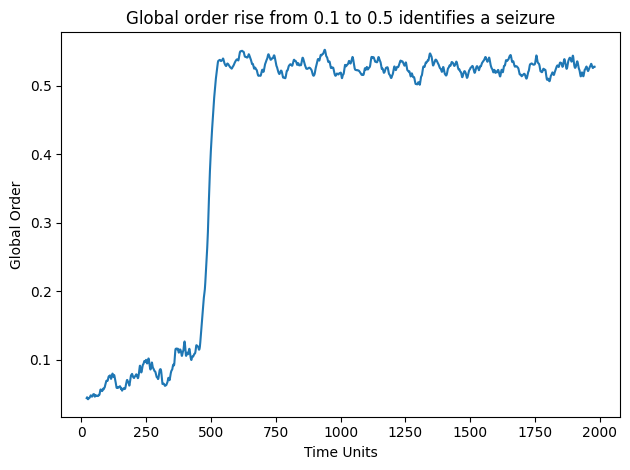

In [13]:
plt.plot(time,df_smooth)
plt.title('Global order rise from 0.1 to 0.5 identifies a seizure')
plt.xlabel('Time Units')
plt.ylabel('Global Order')
plt.tight_layout()
plt.savefig('intro.pdf')

In [34]:
matrix.value_counts()

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [12]:
len_comm

[34, 36, 44, 50, 56, 50, 70, 86]

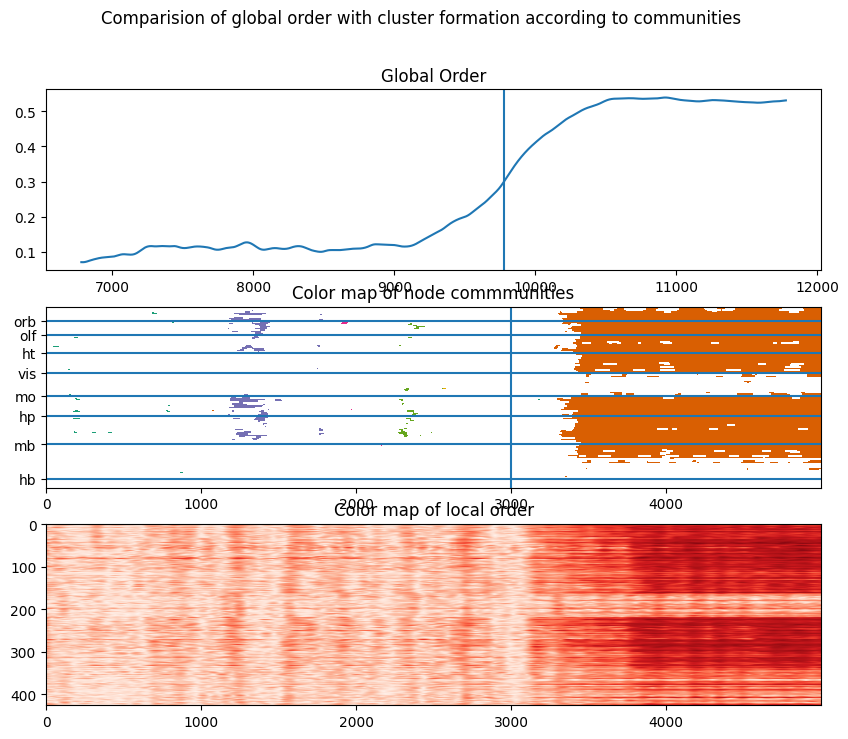

In [116]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
label_in=[]
axs[0].plot(time_steps[cross-3000:cross+2000],df_smooth[cross-3000:cross+2000])
axs[0].set_title('Global Order')
axs[0].axvline(cross)
#axs[0].axvline(6780)
#axs[0].axvline(9780+2000)
#np.place(final_matrix,final_matrix==0,np.nan)
#np.place(final_matrix,final_matrix!=main_cluster_index,-1)
#np.place(final_matrix,final_matrix==main_cluster_index,1)
axs[1].imshow(matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    label_in.append(_i)
    axs[1].axhline(_i)
axs[1].axvline(3000)
label=['orb','olf','ht','vis','mo','hp','mb','hb']

axs[1].set_yticks(label_in)
axs[1].set_yticklabels(label)

#fig.colorbar(cax1, ax=axs[1])
#colorbar=plt.colorbar()
axs[1].set_title('Color map of node commmunities')


axs[2].set_title('Color map of local order')
axs[2].imshow(m_lo_ar.T,cmap='Reds',aspect='auto')
plt.suptitle('Comparision of global order with cluster formation according to communities')
plt.savefig('compa_3_threshold')

In [ ]:
m_lo = (df_lo.loc[8].iloc[0:426]).values
a=m_lo.T
m_lo_ar=a[:,new_order]

#### binarize colormap

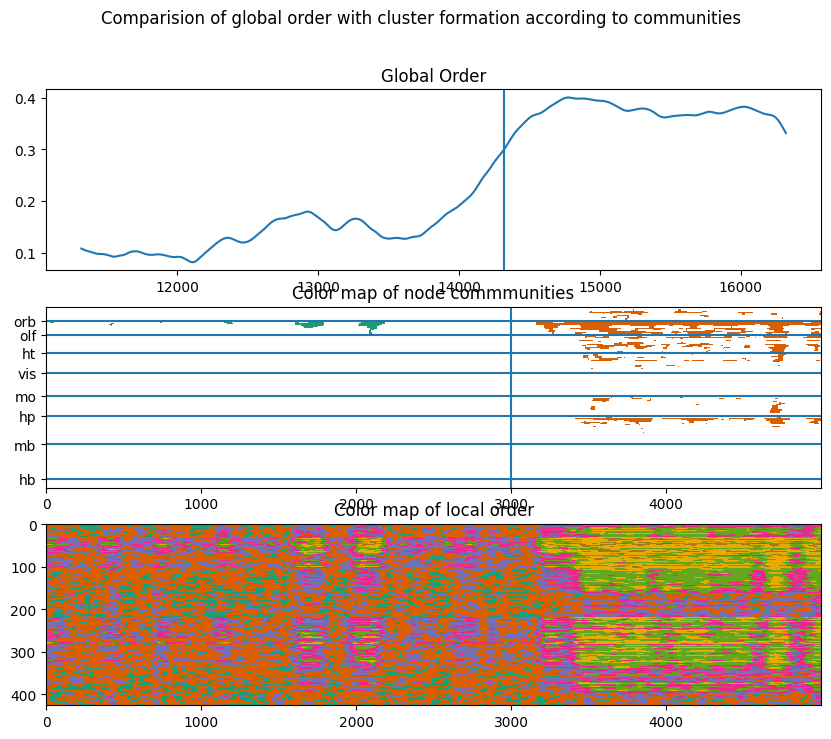

In [47]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
label_in=[]
axs[0].plot(time_steps[cross-3000:cross+2000],df_smooth[cross-3000:cross+2000])
axs[0].set_title('Global Order')
axs[0].axvline(cross)
#axs[0].axvline(6780)
#axs[0].axvline(9780+2000)
#np.place(final_matrix,final_matrix==0,np.nan)

axs[1].imshow(final_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    label_in.append(_i)
    axs[1].axhline(_i)
axs[1].axvline(3000)
label=['orb','olf','ht','vis','mo','hp','mb','hb']

axs[1].set_yticks(label_in)
axs[1].set_yticklabels(label)

#fig.colorbar(cax1, ax=axs[1])
#colorbar=plt.colorbar()
axs[1].set_title('Color map of node commmunities')
np.place(final_matrix,matrix==0,np.nan)

axs[2].set_title('Color map of local order')
axs[2].imshow(m_lo_ar.T,cmap='Dark2',aspect='auto')
plt.suptitle('Comparision of global order with cluster formation according to communities')
plt.savefig('compa_5_binarize')



In [23]:
final_matrix.shape

(5000, 426)

In [24]:
matrix.shape

(5000, 426)

In [74]:
df_nc.index[0]

(1, 0)

In [22]:
len_comm

[34, 36, 44, 50, 56, 50, 70, 86]

In [92]:
np.cumsum(len_comm)

array([ 34,  70, 114, 164, 220, 270, 340, 426])

In [103]:
df_nc.loc[4][22].value_counts()

3.0    1298
Name: 22, dtype: int64

In [123]:
a=df_lo.loc[9].values.T
a_arra=a[:,new_order]

In [122]:
final_matrix.shape

(5000, 426)

#### Plots heatmaps  
Input:  
1. iteration data
2. MB community dictionary
3. local order data
4. node communities data

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create a figure and gridspec
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(4, 2)

# Subplots in the first column
ax1 = fig.add_subplot(gs[0, 0])  # First subplot in the first column
ax2 = fig.add_subplot(gs[1, 0])  # Second subplot in the first column
ax3 = fig.add_subplot(gs[2, 0])  # Third subplot in the first column

# Subplot in the second column
ax4 = fig.add_subplot(gs[:, 1])   # Single subplot in the second column spanning all rows

# Sample data
x = range(10)
y = [i ** 2 for i in x]

# Plotting sample data
ax1.plot(x, y, label='Plot 1')
ax2.plot(x, y, label='Plot 2')
ax3.plot(x, y, label='Plot 3')
ax4.plot(x, y, label='Plot 4')

# Adding titles
ax1.set_title('Subplot 1')
ax2.set_title('Subplot 2')
ax3.set_title('Subplot 3')
ax4.set_title('Subplot 4')

# Display the plot
plt.tight_layout()
plt.show()


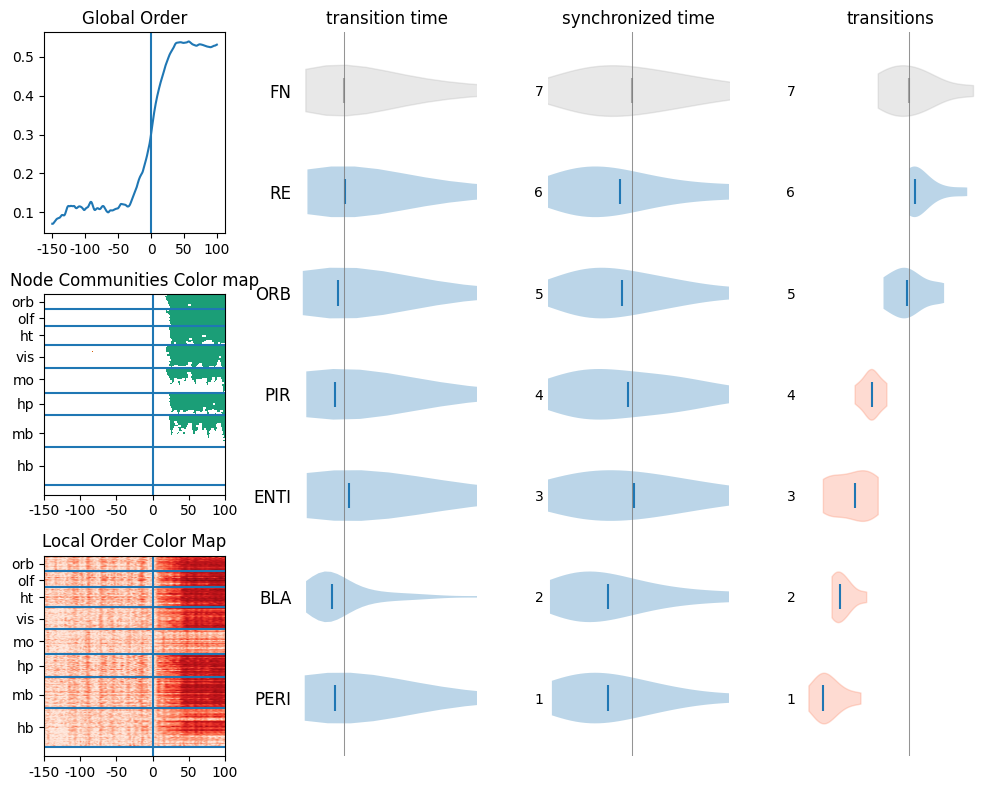

In [39]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create a figure and gridspec
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(3, 4)

# Subplots in the first column
ax1 = fig.add_subplot(gs[0, 0])  # First subplot in the first column
ax2 = fig.add_subplot(gs[1, 0])  # Second subplot in the first column
ax3 = fig.add_subplot(gs[2, 0])  # Third subplot in the first column

# Subplot in the second column
ax4 = fig.add_subplot(gs[:, 1])   # Single subplot in the second column spanning all rows
ax5 = fig.add_subplot(gs[:, 2])
ax6 = fig.add_subplot(gs[:, 3])

itr_num=9
dt=0.05

#put  iteration number for which you want to plot
df_smooth=df_itr['9'].rolling(window=800, center=True).mean()

#defining time and timesteps for data
time_steps = list(range(0,df_smooth.shape[0]))   
time=np.multiply(time_steps,dt)



#Read node community data for a transition
matrix=df_nc.loc[3].values
#Desired order i.e the sequence in which communities enter final cluster  in FN
np.place(matrix,matrix==0,np.nan)

#choosing node 23 as it is from orbital area,making sure it enters the main cluster
main_cluster_index = (df_nc.loc[3])[22].value_counts().index[0]
#the order in which community enters main cluster (may need to check)
desired_keys = [3,6,4,2,0,7,1,5]
#Arranged _x dictionary data in desired order
_x_rearrange = {key: _x[key] for key in desired_keys}
desired_order = [item for sublist in _x_rearrange.values() for item in sublist]
rearranged_matrix = matrix[:, desired_order]
#counting nodes in each community
len_comm=[len(v) for v in _x_rearrange.values()]
#Calculating time spent and sorting in descending order community wise

time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
dict_sort={}

for l in range(0,8):
    #l for iterating communities
    keys=[]
    values=[]
    for i in range(c,last):
        #i for iterating node
        
        for j in range(0,5000):
            #j for iterating timestep
                    
            if rearranged_matrix[j][i] == main_cluster_index:
                time_spent+=1
                        
            else:
                pass
            
        ts.append(time_spent)
        time_spent=0

    keys=list(range(c,last))
    values=ts[c:last]
    dict_0=dict(zip(keys,values))
    sorted_dict_dum = {k: v for k, v in sorted(dict_0.items(), key=lambda item: item[1],reverse=True)}
    dict_sort = dict_sort | sorted_dict_dum
    c=last
    com_count+=1
    if com_count<8:
        last=last+len_comm[com_count]
    else:
        break

#rearranging matrix in the new order
new_order=list(dict_sort.keys())
final_matrix = rearranged_matrix[:, new_order]




m_lo = df_lo.loc[9].values.T

m_lo_ar=m_lo[:, new_order]


cross = df_smooth[df_smooth>0.3].index[0]

#fig, axs = plt.subplots(3, 1, figsize=(12, 10))
label_in=[]
#x_scale = [(m-3000) for m in (time_steps[cross-3000:cross+2000])]
ax1.plot(time_steps[cross-3000:cross+2000],df_smooth[cross-3000:cross+2000])
xtick=[cross-3000,cross-2000,cross-1000,cross,cross+1000,cross+2000]
ax1.set_xticks(xtick) 
ax1.set_xticklabels([int((x - cross)*0.05) for x in xtick])
ax1.set_title('Global Order')
ax1.axvline(cross)
#axs[0].axvline(6780)
#axs[0].axvline(9780+2000)
#np.place(final_matrix,final_matrix==0,np.nan)
#np.place(final_matrix,final_matrix!=main_cluster_index,-1)
#np.place(final_matrix,final_matrix==main_cluster_index,1)
ax2.imshow(final_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    ax2.axhline(_i)
ax2.axvline(3000)
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
ax2.set_xticks(xc_tick) 
ax2.set_xticklabels([int((x - 3000)*0.05) for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
ax2.set_yticks(label_in)
ax2.set_yticklabels(label)

#fig.colorbar(cax1, ax=axs[1])
#colorbar=plt.colorbar()
ax2.set_title('Node Communities Color map')


ax3.set_title('Local Order Color Map')
ax3.imshow(m_lo_ar.T,cmap='Reds',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    ax3.axhline(_i)
ax3.axvline(3000)
ax3.set_xticks(xc_tick) 
ax3.set_xticklabels([int((x - 3000)*0.05) for x in xc_tick])
ax3.set_yticks(label_in)
ax3.set_yticklabels(label)







# f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(5, 8), sharey=True)
#ax4, (a1, a2, a3) = plt.subplots(1, 3, figsize=(5, 8), sharey=True)

_artists = ax4.violinplot([transition_times[k] for k in node_order[non]], vert=False, showextrema=False, showmedians=True)
ax4.set_yticks(np.arange(1, len(node_order)+1))
ax4.set_yticklabels(node_order[non], fontsize=12)
_artists['bodies'][-1].set_color(cm.Greys(0.4, 0.4))
_artists['cmedians'].set_color(list(_artists['cmedians'].get_color())*6+[cm.Greys(0.8, 0.4)])
ax4.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
ax4.set_xticks([])
ax4.set_xlim(20, 100)
ax4.tick_params(axis=u'both', which=u'both', length=0)
ax4.set_title('transition time')
ax4.axvline(np.median(transition_times['FN']), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax5.violinplot([sync_times[k] for k in node_order[non]], vert=False, showextrema=False, showmedians=True)
# ax2.set_yticks(np.arange(1, len(node_order)+1))
# ax1.set_yticklabels(node_order)
_artists['bodies'][-1].set_color(cm.Greys(0.4, 0.4))
_artists['cmedians'].set_color(list(_artists['cmedians'].get_color())*6+[cm.Greys(0.8, 0.4)])
ax5.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
ax5.set_xticks([])
ax5.set_xlim(80, 500)
ax5.tick_params(axis=u'both', which=u'both', length=0)
ax5.set_title('synchronized time')
ax5.axvline(np.median(sync_times['FN']), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax6.violinplot([np.diff(np.array(n_trans[k])) for k in node_order[non]], vert=False, showextrema=False, showmedians=True)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists['bodies'][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists['bodies'][i].set_color(cm.Reds(0.4, 0.4))
_artists['cmedians'].set_color(list(_artists['cmedians'].get_color())*6+[cm.Greys(0.8, 0.4)])
ax6.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
ax6.set_xticks([])
# ax3.set_xlim(80, 500)
ax6.tick_params(axis=u'both', which=u'both', length=0)
ax6.set_title('transitions')
ax6.axvline(np.median(np.diff(n_trans['FN'])), c=cm.Greys(0.6, 0.8), lw=0.75)


plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.tight_layout()
# # requires `metrics` which is loaded in 'All networks' section
# _artists = ax4.violinplot(metrics['high'].unstack(level='noi', sort=False).apply(lambda c: list(c.dropna())), vert=False, showextrema=False, showmedians=True)
# # ax3.set_yticks(np.arange(1, len(node_order)+1))
# # ax3.set_yticklabels(node_order)
# _artists['bodies'][-1].set_color(cm.Greys(0.4, 0.4))
# for i in range(4):
#     _artists['bodies'][i].set_color(cm.Reds(0.4, 0.4))
# _artists['cmedians'].set_color(list(_artists['cmedians'].get_color())*6+[cm.Greys(0.8, 0.4)])
# ax4.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
# ax4.set_xticks([])
# # ax3.set_xlim(80, 500)
# ax4.tick_params(axis=u'both', which=u'both', length=0)
# ax4.set_title('sync level')
# ax4.axvline(metrics['high'].loc['FN'].median(), c=cm.Greys(0.6, 0.8), lw=0.75)

#ax4.subplots_adjust(wspace=0.8)
plt.savefig('results.png')

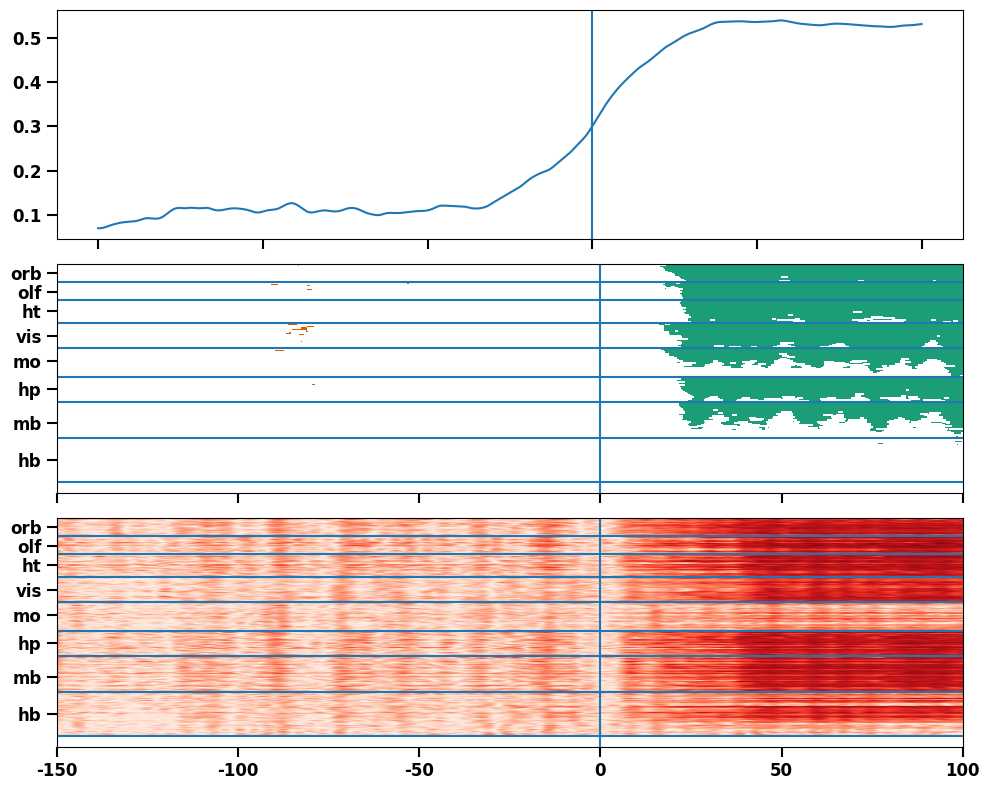

In [33]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create a figure and gridspec
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(3, 1)

# Subplots in the first column
ax1 = fig.add_subplot(gs[0, 0])  # First subplot in the first column
ax2 = fig.add_subplot(gs[1, 0])  # Second subplot in the first column
ax3 = fig.add_subplot(gs[2, 0])  # Third subplot in the first column



itr_num=9
dt=0.05

#put  iteration number for which you want to plot
df_smooth=df_itr['9'].rolling(window=800, center=True).mean()

#defining time and timesteps for data
time_steps = list(range(0,df_smooth.shape[0]))   
time=np.multiply(time_steps,dt)



#Read node community data for a transition
matrix=df_nc.loc[3].values
#Desired order i.e the sequence in which communities enter final cluster  in FN
np.place(matrix,matrix==0,np.nan)

#choosing node 23 as it is from orbital area,making sure it enters the main cluster
main_cluster_index = (df_nc.loc[3])[22].value_counts().index[0]
#the order in which community enters main cluster (may need to check)
desired_keys = [3,6,4,2,0,7,1,5]
#Arranged _x dictionary data in desired order
_x_rearrange = {key: _x[key] for key in desired_keys}
desired_order = [item for sublist in _x_rearrange.values() for item in sublist]
rearranged_matrix = matrix[:, desired_order]
#counting nodes in each community
len_comm=[len(v) for v in _x_rearrange.values()]
#Calculating time spent and sorting in descending order community wise

time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
dict_sort={}

for l in range(0,8):
    #l for iterating communities
    keys=[]
    values=[]
    for i in range(c,last):
        #i for iterating node
        
        for j in range(0,5000):
            #j for iterating timestep
                    
            if rearranged_matrix[j][i] == main_cluster_index:
                time_spent+=1
                        
            else:
                pass
            
        ts.append(time_spent)
        time_spent=0

    keys=list(range(c,last))
    values=ts[c:last]
    dict_0=dict(zip(keys,values))
    sorted_dict_dum = {k: v for k, v in sorted(dict_0.items(), key=lambda item: item[1],reverse=True)}
    dict_sort = dict_sort | sorted_dict_dum
    c=last
    com_count+=1
    if com_count<8:
        last=last+len_comm[com_count]
    else:
        break

#rearranging matrix in the new order
new_order=list(dict_sort.keys())
final_matrix = rearranged_matrix[:, new_order]




m_lo = df_lo.loc[9].values.T

m_lo_ar=m_lo[:, new_order]


cross = df_smooth[df_smooth>0.3].index[0]

#fig, axs = plt.subplots(3, 1, figsize=(12, 10))
label_in=[]
#x_scale = [(m-3000) for m in (time_steps[cross-3000:cross+2000])]
ax1.plot(time_steps[cross-3000:cross+2000],df_smooth[cross-3000:cross+2000])
xtick=[cross-3000,cross-2000,cross-1000,cross,cross+1000,cross+2000]
label1=[int((x - cross)*0.05) for x in xtick]
ax1.set_xticks(xtick) 
ax1.set_xticklabels([])
#ax1.set_title('Global Order')
ax1.axvline(cross)
ax1.tick_params(axis='both', which='major', labelcolor='black', color='black', labelsize=12,width=1.5,length=7.5)
#axs[0].axvline(6780)
#axs[0].axvline(9780+2000)
#np.place(final_matrix,final_matrix==0,np.nan)
#np.place(final_matrix,final_matrix!=main_cluster_index,-1)
#np.place(final_matrix,final_matrix==main_cluster_index,1)
for mo in ax1.get_xticklabels() + ax1.get_yticklabels(): 
    mo.set_fontweight('bold')
ax2.imshow(final_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    ax2.axhline(_i)
ax2.axvline(3000)
ax2.tick_params(axis='both', which='major', labelcolor='black', color='black', labelsize=12,width=1.5,length=7.5)
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
ax2.set_xticks(xc_tick) 
ax2.set_xticklabels([])
label_in=[17,54,92,140,190,245,310,383]
ax2.set_yticks(label_in)
ax2.set_yticklabels(label)
for l in ax2.get_xticklabels() + ax2.get_yticklabels(): 
    l.set_fontweight('bold')
#fig.colorbar(cax1, ax=axs[1])
#colorbar=plt.colorbar()
#ax2.set_title('Node Communities Color map')


#ax3.set_title('Local Order Color Map')
ax3.imshow(m_lo_ar.T,cmap='Reds',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    ax3.axhline(_i)
ax3.axvline(3000)

ax3.tick_params(axis='both', which='major', labelcolor='black', color='black', labelsize=12,width=1.5,length=7.5)
ax3.set_xticks(xc_tick) 
ax3.set_xticklabels([int((x - 3000)*0.05) for x in xc_tick])
ax3.set_yticks(label_in)
ax3.set_yticklabels(label)
for label in ax3.get_xticklabels() + ax3.get_yticklabels(): 
    label.set_fontweight('bold')





plt.subplots_adjust(wspace=0.2, hspace=0.2)

plt.tight_layout()
plt.savefig('results.png')

In [14]:
import sys
from os import path
from glob import glob
import pickle

sys.path.append('../analysis')
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
import networkx as nx

In [15]:
processed_folder = '../../data/processed/'
raw_folder = '../../data/raw/'

node_order = np.array(['FN', 'PERI', 'RE', 'ENTI', 'ORB', 'BLA', 'PIR'])
node_c_avi =  ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]
node_c_nim = ['#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080']
color_seq =['ORB', 'MO', 'VIS', 'OLF', 'HTh', 'HIPP','MID','HIND']

node_c_avi = dict(zip(color_seq, node_c_avi))
node_c_nim = dict(zip(color_seq, node_c_nim))

In [16]:
# read transition time data
transition_times = {}
for f in glob(path.join(processed_folder, 'tt*.bz2')):
    df = pd.read_pickle(f, compression='bz2').rename({'Full Network':'FN'}, axis=1)
    transition_times[df.columns[0]] = df.iloc[:, 0].values

# read synchronized time data
sync_times = {}
for f in glob(path.join(processed_folder, 'st*.bz2')):
    df = pd.read_pickle(f, compression='bz2').rename({'Full Network':'FN'}, axis=1)
    sync_times[df.columns[0]] = df.iloc[:, 0].values

# read number of transitions data
with open(path.join(processed_folder, 'tran_num.pkl'), 'rb') as f:
    n_trans = pickle.load(f)

# define node order based on the number of transitions
non = np.r_[np.argsort([n_trans[k][-1]/1000 for k in node_order[1:]])+1, 0]

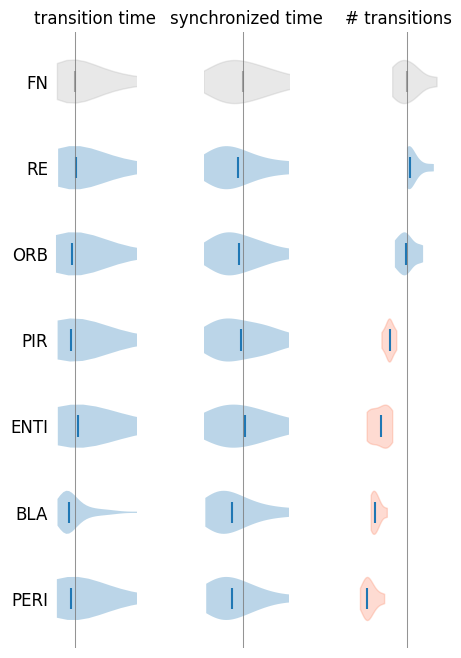

In [17]:
# f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(5, 8), sharey=True)
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(5, 8), sharey=True)

_artists = ax1.violinplot([transition_times[k] for k in node_order[non]], vert=False, showextrema=False, showmedians=True)
ax1.set_yticks(np.arange(1, len(node_order)+1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists['bodies'][-1].set_color(cm.Greys(0.4, 0.4))
_artists['cmedians'].set_color(list(_artists['cmedians'].get_color())*6+[cm.Greys(0.8, 0.4)])
ax1.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 100)
ax1.tick_params(axis=u'both', which=u'both', length=0)
ax1.set_title('transition time')
ax1.axvline(np.median(transition_times['FN']), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax2.violinplot([sync_times[k] for k in node_order[non]], vert=False, showextrema=False, showmedians=True)
# ax2.set_yticks(np.arange(1, len(node_order)+1))
# ax1.set_yticklabels(node_order)
_artists['bodies'][-1].set_color(cm.Greys(0.4, 0.4))
_artists['cmedians'].set_color(list(_artists['cmedians'].get_color())*6+[cm.Greys(0.8, 0.4)])
ax2.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
ax2.set_xticks([])
ax2.set_xlim(80, 500)
ax2.tick_params(axis=u'both', which=u'both', length=0)
ax2.set_title('synchronized time')
ax2.axvline(np.median(sync_times['FN']), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax3.violinplot([np.diff(np.array(n_trans[k])) for k in node_order[non]], vert=False, showextrema=False, showmedians=True)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists['bodies'][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists['bodies'][i].set_color(cm.Reds(0.4, 0.4))
_artists['cmedians'].set_color(list(_artists['cmedians'].get_color())*6+[cm.Greys(0.8, 0.4)])
ax3.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
ax3.set_xticks([])
# ax3.set_xlim(80, 500)
ax3.tick_params(axis=u'both', which=u'both', length=0)
ax3.set_title('# transitions')
ax3.axvline(np.median(np.diff(n_trans['FN'])), c=cm.Greys(0.6, 0.8), lw=0.75)

# # requires `metrics` which is loaded in 'All networks' section
# _artists = ax4.violinplot(metrics['high'].unstack(level='noi', sort=False).apply(lambda c: list(c.dropna())), vert=False, showextrema=False, showmedians=True)
# # ax3.set_yticks(np.arange(1, len(node_order)+1))
# # ax3.set_yticklabels(node_order)
# _artists['bodies'][-1].set_color(cm.Greys(0.4, 0.4))
# for i in range(4):
#     _artists['bodies'][i].set_color(cm.Reds(0.4, 0.4))
# _artists['cmedians'].set_color(list(_artists['cmedians'].get_color())*6+[cm.Greys(0.8, 0.4)])
# ax4.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
# ax4.set_xticks([])
# # ax3.set_xlim(80, 500)
# ax4.tick_params(axis=u'both', which=u'both', length=0)
# ax4.set_title('sync level')
# ax4.axvline(metrics['high'].loc['FN'].median(), c=cm.Greys(0.6, 0.8), lw=0.75)

f.subplots_adjust(wspace=0.8)

In [63]:
main_cluster_index

2.0

#### 